# Контрольные расчёты - Junior Data Analyst

В этом ноутбуке я проверяю числовые ответы из `README.md`. Для расчётов использую стандартную библиотеку Python.

## Краткие результаты

- Ожидаемое число видов животных: **3,99**.
- Ожидаемое число победителей двух этапов: **26,8**.
- Вероятности появления автомобиля: **63,2%** за 10 минут и **93,3%** за 27 минут.
- ROC-AUC: **0,75**.
- Корреляция Пирсона: **-0,85**.
- Симуляции Монте-Карло подтверждают ответы задач про фермера и поваров.

## Допущения

Цель - воспроизвести числовые ответы и проверить Python-функции.

### Что предполагаю

1. Вид животного при каждом посещении выбирается равновероятно и независимо.
2. Паросочетания двух этапов независимы.
3. Появление автомобилей описывается стационарным пуассоновским процессом.
4. ROC-AUC считается по непрерывным оценкам вероятности, а не по меткам при пороге 0,6.

## Исходные данные

In [1]:
import random

import matplotlib.pyplot as plt

from solutions import (
    event_probability,
    expected_distinct_species,
    expected_two_round_winners,
    is_isomorphic,
    missing_number,
    pearson_correlation,
    prime_factors,
    roc_auc_from_pairs,
)

BLUE = "#3267A8"
ORANGE = "#D9822B"
INK = "#263238"
GRID = "#D9DEE3"

labels = [1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0]
probabilities = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25]
coffee = [1, 1, 2, 2, 2, 2, 3, 3, 3, 4]
exam_scores = [85, 88, 79, 81, 84, 65, 67, 58, 76, 49]

Matplotlib is building the font cache; this may take a moment.


## Расчёты

### 1. Теория вероятностей

In [2]:
farmer = expected_distinct_species()
cooks = expected_two_round_winners()
car_10 = event_probability(0.95, 30, 10)
car_27 = event_probability(0.95, 30, 27)

results = {
    'Фермер': round(farmer, 2),
    'Кулинарное соревнование': round(cooks, 1),
    'Автомобиль, 10 минут, %': round(car_10 * 100, 1),
    'Автомобиль, 27 минут, %': round(car_27 * 100, 1),
}
results

{'Фермер': 3.99,
 'Кулинарное соревнование': 26.8,
 'Автомобиль, 10 минут, %': 63.2,
 'Автомобиль, 27 минут, %': 93.3}

#### Проверка задач про фермера и поваров симуляцией

Для проверки формул использую 20 000 испытаний с фиксированным seed. Симуляция не заменяет аналитическое решение, а служит независимой проверкой.

In [3]:
SIMULATION_RUNS = 20_000
simulation_rng = random.Random(20260813)

farmer_total = 0
for _ in range(SIMULATION_RUNS):
    observed_species = {simulation_rng.randrange(6) for _ in range(6)}
    farmer_total += len(observed_species)
farmer_simulated = farmer_total / SIMULATION_RUNS


def simulate_round_winners(rng):
    participants = list(range(80))
    rng.shuffle(participants)
    return {
        max(participants[index], participants[index + 1])
        for index in range(0, 80, 2)
    }


cooks_total = 0
for _ in range(SIMULATION_RUNS):
    first_round = simulate_round_winners(simulation_rng)
    second_round = simulate_round_winners(simulation_rng)
    cooks_total += len(first_round & second_round)
cooks_simulated = cooks_total / SIMULATION_RUNS

{
    'Фермер, формула': round(farmer, 4),
    'Фермер, симуляция': round(farmer_simulated, 4),
    'Повара, формула': round(cooks, 4),
    'Повара, симуляция': round(cooks_simulated, 4),
}

{'Фермер, формула': 3.9906,
 'Фермер, симуляция': 3.9935,
 'Повара, формула': 26.8354,
 'Повара, симуляция': 26.8122}

### 2. Python-функции

In [4]:
python_checks = {
    'paper/title': is_isomorphic('paper', 'title'),
    'foo/bar': is_isomorphic('foo', 'bar'),
    'missing': missing_number([1, 2, 3, 4, 5, 6, 8, 9, 10, 11]),
    'factors_56': prime_factors(56),
}
python_checks

{'paper/title': True,
 'foo/bar': False,
 'missing': 7,
 'factors_56': [2, 2, 2, 7]}

### 3. ROC-AUC

In [5]:
positive_scores = [score for label, score in zip(labels, probabilities) if label == 1]
negative_scores = [score for label, score in zip(labels, probabilities) if label == 0]
concordant_pairs = sum(pos > neg for pos in positive_scores for neg in negative_scores)
total_pairs = len(positive_scores) * len(negative_scores)
auc = roc_auc_from_pairs(labels, probabilities)
{'concordant_pairs': concordant_pairs, 'total_pairs': total_pairs, 'roc_auc': auc}

{'concordant_pairs': 42, 'total_pairs': 56, 'roc_auc': 0.75}

#### ROC-кривая

Кривая строится по оценкам вероятности при всех возможных порогах. Пунктирная диагональ соответствует случайному ранжированию.

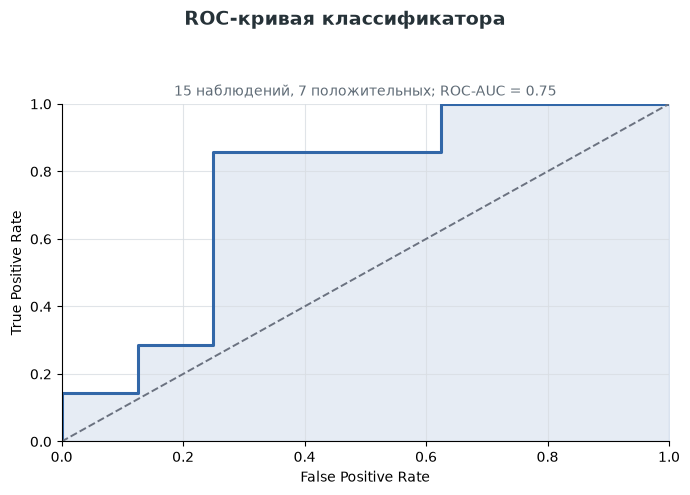

In [6]:
thresholds = [float('inf')] + sorted(set(probabilities), reverse=True)
positive_count = sum(labels)
negative_count = len(labels) - positive_count
roc_points = []

for threshold in thresholds:
    predictions = [score >= threshold for score in probabilities]
    true_positives = sum(predicted and label == 1 for predicted, label in zip(predictions, labels))
    false_positives = sum(predicted and label == 0 for predicted, label in zip(predictions, labels))
    roc_points.append((false_positives / negative_count, true_positives / positive_count))

false_positive_rates, true_positive_rates = zip(*roc_points)

fig, ax = plt.subplots(figsize=(7, 5))
ax.step(false_positive_rates, true_positive_rates, where='post', color=BLUE, linewidth=2.2)
ax.plot([0, 1], [0, 1], linestyle='--', color='#6B7280', linewidth=1.4)
ax.fill_between(false_positive_rates, true_positive_rates, step='post', alpha=0.12, color=BLUE)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='False Positive Rate', ylabel='True Positive Rate')
fig.suptitle('ROC-кривая классификатора', fontsize=14, fontweight='bold', color=INK)
ax.set_title(f'15 наблюдений, 7 положительных; ROC-AUC = {auc:.2f}', fontsize=10, color='#5F6B76')
ax.grid(True, color=GRID, linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### 4. Корреляция Пирсона

In [7]:
correlation = pearson_correlation(coffee, exam_scores)
{'pearson_r': correlation, 'rounded': round(correlation, 2)}

{'pearson_r': -0.8492696876732622, 'rounded': -0.85}

#### Кофе и экзаменационный балл

Точки показывают отдельных студентов, линия - линейный тренд. Выборка небольшая (`n = 10`), поэтому график описывает только наблюдаемую связь.

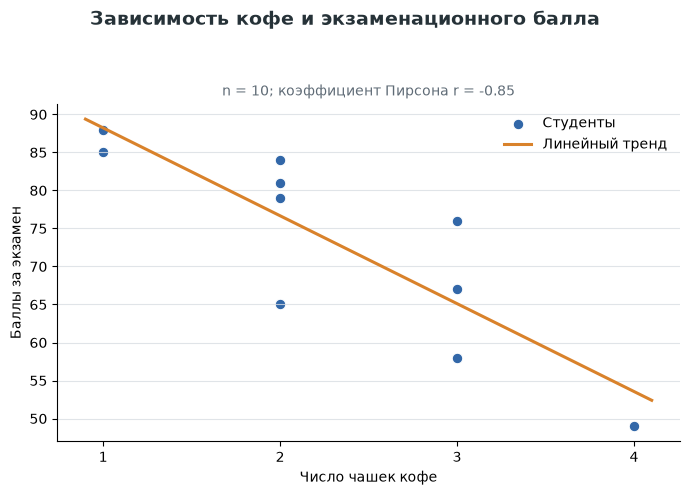

In [8]:
coffee_mean = sum(coffee) / len(coffee)
score_mean = sum(exam_scores) / len(exam_scores)
trend_slope = sum(
    (cups - coffee_mean) * (score - score_mean)
    for cups, score in zip(coffee, exam_scores)
) / sum((cups - coffee_mean) ** 2 for cups in coffee)
trend_intercept = score_mean - trend_slope * coffee_mean
trend_x = [min(coffee) - 0.1, max(coffee) + 0.1]
trend_y = [trend_slope * cups + trend_intercept for cups in trend_x]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coffee, exam_scores, s=58, color=BLUE, edgecolor='white', linewidth=0.8, label='Студенты')
ax.plot(trend_x, trend_y, color=ORANGE, linewidth=2.2, label='Линейный тренд')
ax.set(xlabel='Число чашек кофе', ylabel='Баллы за экзамен')
ax.set_xticks(sorted(set(coffee)))
fig.suptitle('Зависимость кофе и экзаменационного балла', fontsize=14, fontweight='bold', color=INK)
ax.set_title(f'n = {len(coffee)}; коэффициент Пирсона r = {correlation:.2f}', fontsize=10, color='#5F6B76')
ax.grid(axis='y', color=GRID, linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='upper right')
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### 5. Контрольные утверждения

In [9]:
assert round(farmer, 2) == 3.99
assert round(cooks, 1) == 26.8
assert round(car_10 * 100, 1) == 63.2
assert round(car_27 * 100, 1) == 93.3
assert abs(farmer_simulated - farmer) < 0.05
assert abs(cooks_simulated - cooks) < 0.15
assert auc == 0.75
assert round(correlation, 2) == -0.85
assert python_checks == {
    'paper/title': True,
    'foo/bar': False,
    'missing': 7,
    'factors_56': [2, 2, 2, 7],
}
'Все контрольные проверки пройдены.'

'Все контрольные проверки пройдены.'

## Вывод

Числовые ответы совпали с независимыми формулами и симуляциями. ROC-кривая подтверждает AUC 0,75. На графике кофе и баллов видна сильная отрицательная линейная связь, но она не доказывает причинность. Подробные статистические, SQL- и ML-пояснения приведены в `README.md`.